# Linear Regression in R (AI-assisted)

This notebook builds a simple linear regression model to predict **Salary** from **YearsExperience** using `regression_data.csv`.

Steps:
1. Read the CSV
2. Create a scatter plot
3. Fit a linear model
4. Overlay the regression line
5. Evaluate the model

## 1. Load libraries

In [1]:
library(ggplot2)

## 2. Read the CSV file

In [2]:
data <- read.csv("../regression_data.csv")
print(head(data))
cat("\nNumber of rows:", nrow(data), "\n")
cat("Columns:", paste(colnames(data), collapse = ", "), "\n")

  YearsExperience Salary
1             1.1  39343
2             1.3  46205
3             1.5  37731
4             2.0  43525
5             2.2  39891
6             2.9  56642



Number of rows: 10 


Columns: YearsExperience, Salary 


## 3. Create a scatter plot

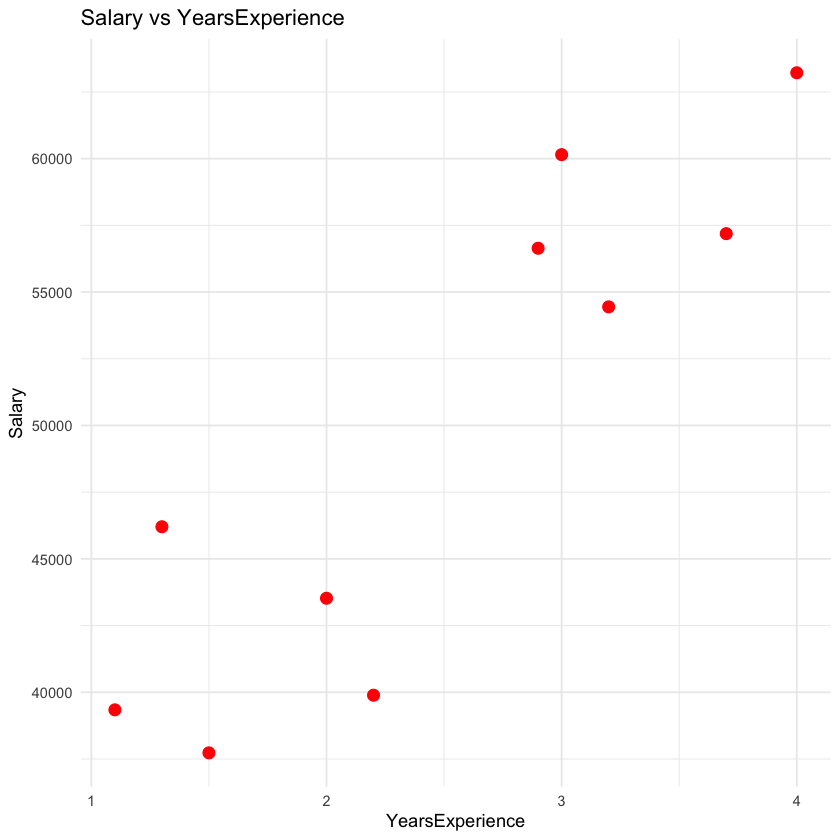

In [3]:
x_col <- "YearsExperience"
y_col <- "Salary"

ggplot(data, aes(x = .data[[x_col]], y = .data[[y_col]])) +
  geom_point(color = "red", size = 3) +
  ggtitle(paste(y_col, "vs", x_col)) +
  xlab(x_col) +
  ylab(y_col) +
  theme_minimal()

## 4. Fit a linear model

In [4]:
formula <- as.formula(paste(y_col, "~", x_col))
model <- lm(formula, data = data)

print(summary(model))

intercept <- coef(model)[1]
slope <- coef(model)[2]
cat("\nModel equation:", y_col, "=", round(intercept, 2), "+", round(slope, 2), "*", x_col, "\n")


Call:
lm(formula = formula, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-7540.2 -2564.9  -199.1  2814.8  6230.6 

Coefficients:
                Estimate Std. Error t value Pr(>|t|)    
(Intercept)        29204       4092   7.136 9.84e-05 ***
YearsExperience     8285       1532   5.407 0.000641 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 4680 on 8 degrees of freedom
Multiple R-squared:  0.7852,	Adjusted R-squared:  0.7583 
F-statistic: 29.24 on 1 and 8 DF,  p-value: 0.0006407




Model equation: Salary = 29203.52 + 8285.29 * YearsExperience 


## 5. Overlay the regression line

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


Saved plot: linear_regression_r_output.png


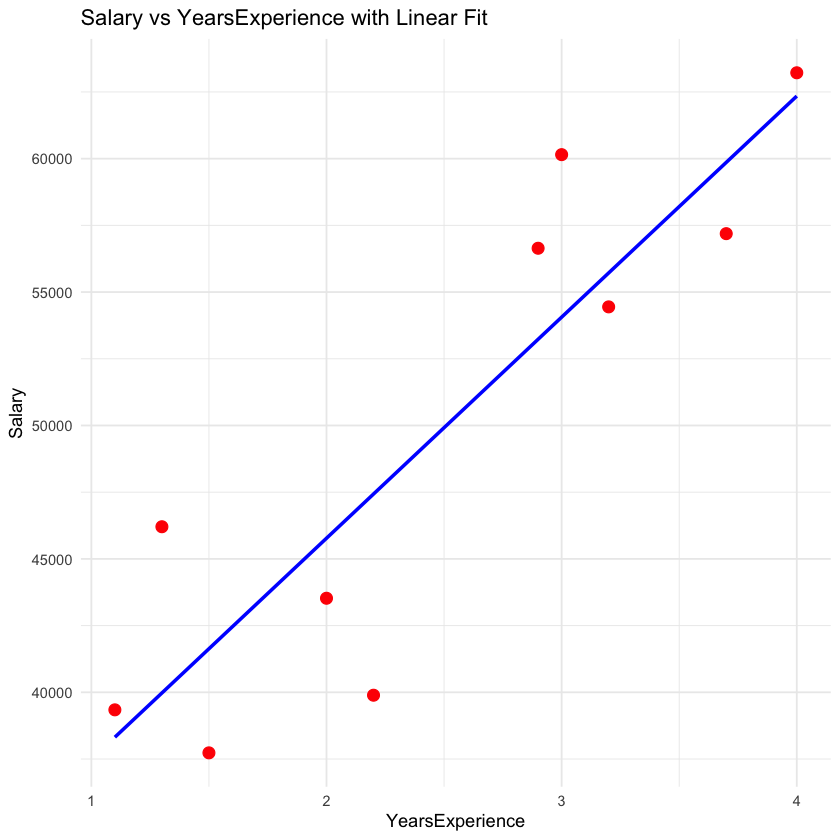

In [5]:
plot <- ggplot(data, aes(x = .data[[x_col]], y = .data[[y_col]])) +
  geom_point(color = "red", size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "blue", linewidth = 1) +
  ggtitle(paste(y_col, "vs", x_col, "with Linear Fit")) +
  xlab(x_col) +
  ylab(y_col) +
  theme_minimal()

print(plot)
ggsave("linear_regression_r_output.png", plot = plot, width = 8, height = 5, dpi = 150)
cat("Saved plot: linear_regression_r_output.png\n")

## 6. Evaluate the model

In [6]:
y_actual <- data[[y_col]]
y_pred <- predict(model)

r2 <- summary(model)$r.squared
adj_r2 <- summary(model)$adj.r.squared
mse <- mean((y_actual - y_pred)^2)
rmse <- sqrt(mse)
mae <- mean(abs(y_actual - y_pred))

cat("Model evaluation metrics:\n")
cat(sprintf("  R-squared (R²):         %.4f\n", r2))
cat(sprintf("  Adjusted R-squared:     %.4f\n", adj_r2))
cat(sprintf("  Mean Squared Error:     %.2f\n", mse))
cat(sprintf("  Root Mean Squared Err:  %.2f\n", rmse))
cat(sprintf("  Mean Absolute Error:    %.2f\n", mae))
cat("\nInterpretation:\n")
cat(sprintf("  About %.1f%% of the variation in %s is explained by %s.\n", r2 * 100, y_col, x_col))

Model evaluation metrics:


  R-squared (R²):         0.7852


  Adjusted R-squared:     0.7583


  Mean Squared Error:     17523844.08


  Root Mean Squared Err:  4186.15


  Mean Absolute Error:    3526.26



Interpretation:


  About 78.5% of the variation in Salary is explained by YearsExperience.
